# Loan Default Risk Classifier

**A cost-sensitive credit risk model for consumer loan approval decisions**

## Business Problem

When a bank or lender evaluates a loan application, it faces two asymmetric risks:

- **Rejecting a good applicant** → lost interest income (moderate cost)
- **Approving a bad applicant** → potential principal loss (severe cost)

A naive classifier optimized purely for accuracy treats both mistakes as equally bad. In practice,
lenders weight them very differently. This project builds a loan default risk classifier that is
**explicitly cost-sensitive**, follows an approach used for credit risk scoring during my internship
at Banque Misr's Digital, AI & Data Governance department (feature engineering + classification
for loan approval decisioning).

**Note on data:** the dataset used here is the public UCI Statlog German Credit dataset (1,000
loan applicants, 20 attributes), not proprietary Banque Misr data. The methodology mirrors a
production credit-risk workflow: EDA → feature engineering → cost-sensitive model comparison →
business-facing evaluation.

## What this notebook covers
1. Data loading & decoding
2. Exploratory data analysis
3. Feature engineering (encoding, scaling)
4. Model training: Logistic Regression (baseline), Random Forest, XGBoost
5. Cost-sensitive evaluation (not just accuracy)
6. Feature importance & business interpretation


In [1]:
import sys
sys.path.append('src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from load_data import load_decoded

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)

pd.set_option('display.max_columns', 25)


## 1. Data Loading

Loading and decoding the raw dataset (original categorical codes like `A11`, `A34` are mapped to
readable labels). Target variable `default_risk`: `1` = high default risk (bad credit), `0` = good
credit risk.

In [2]:
df = load_decoded()
print(f"Shape: {df.shape}")
df.head()

Shape: (1000, 21)


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct,personal_status_sex,other_debtors_guarantors,present_residence_since,property,age_years,other_installment_plans,housing,existing_credits_count,job,people_liable,telephone,foreign_worker,default_risk
0,< 0 DM,6,critical account / other credits existing,radio/television,1169,unknown/no savings account,>= 7 years,4,male: single,none,4,real estate,67,none,own,2,skilled employee/official,1,"yes, registered",yes,0
1,0-200 DM,48,existing credits paid back duly,radio/television,5951,< 100 DM,1-4 years,2,female: divorced/separated/married,none,2,real estate,22,none,own,1,skilled employee/official,1,none,yes,1
2,no checking account,12,critical account / other credits existing,education,2096,< 100 DM,4-7 years,2,male: single,none,3,real estate,49,none,own,1,unskilled resident,2,none,yes,0
3,< 0 DM,42,existing credits paid back duly,furniture/equipment,7882,< 100 DM,4-7 years,2,male: single,guarantor,4,building society savings/life insurance,45,none,for free,1,skilled employee/official,2,none,yes,0
4,< 0 DM,24,delay in past payments,new car,4870,< 100 DM,1-4 years,3,male: single,none,4,unknown/no property,53,none,for free,2,skilled employee/official,2,none,yes,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   checking_account_status   1000 non-null   str  
 1   duration_months           1000 non-null   int64
 2   credit_history            1000 non-null   str  
 3   purpose                   1000 non-null   str  
 4   credit_amount             1000 non-null   int64
 5   savings_account           1000 non-null   str  
 6   employment_since          1000 non-null   str  
 7   installment_rate_pct      1000 non-null   int64
 8   personal_status_sex       1000 non-null   str  
 9   other_debtors_guarantors  1000 non-null   str  
 10  present_residence_since   1000 non-null   int64
 11  property                  1000 non-null   str  
 12  age_years                 1000 non-null   int64
 13  other_installment_plans   1000 non-null   str  
 14  housing                   1000 non-null   str  
 15 

## 2. Exploratory Data Analysis

### 2.1 Class balance

The dataset is imbalanced: 70% good credit risk vs 30% bad. This matters for both model choice
and evaluation metric choice (accuracy alone would be misleading — a model predicting "good" for
everyone gets 70% accuracy while being business-useless).

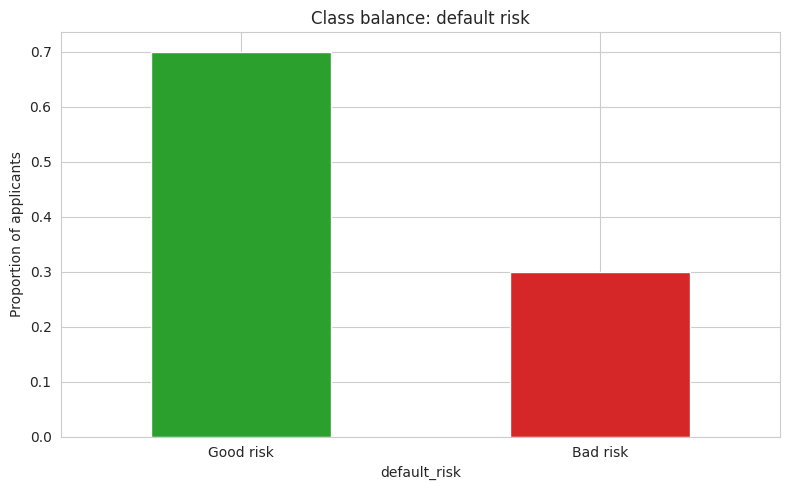

In [4]:
ax = df['default_risk'].value_counts(normalize=True).rename({0: 'Good risk', 1: 'Bad risk'}).plot(
    kind='bar', color=['#2ca02c', '#d62728'])
ax.set_ylabel('Proportion of applicants')
ax.set_title('Class balance: default risk')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 2.2 Key numeric features vs default risk

/tmp/ipykernel_620/1678608431.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='default_risk', y=col, ax=ax, palette=['#2ca02c', '#d62728'])
/tmp/ipykernel_620/1678608431.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Good', 'Bad'])
/tmp/ipykernel_620/1678608431.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='default_risk', y=col, ax=ax, palette=['#2ca02c', '#d62728'])
/tmp/ipykernel_620/1678608431.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([

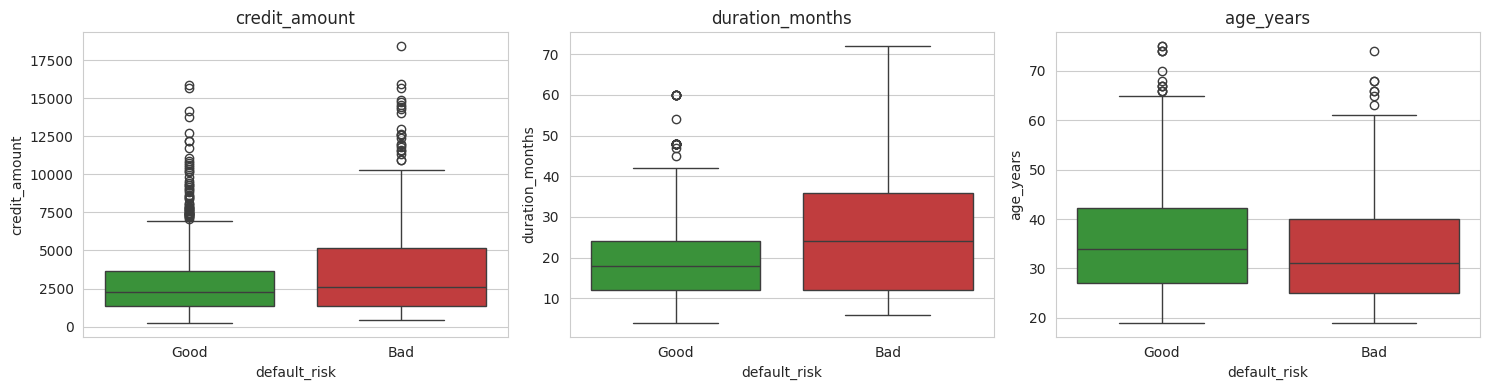

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['credit_amount', 'duration_months', 'age_years']):
    sns.boxplot(data=df, x='default_risk', y=col, ax=ax, palette=['#2ca02c', '#d62728'])
    ax.set_xticklabels(['Good', 'Bad'])
    ax.set_title(col)
plt.tight_layout()
plt.show()

Applicants who default tend to request larger loan amounts over longer durations — consistent
with intuition: bigger, longer-term loans carry more repayment risk.

### 2.3 Checking account status vs default risk

Checking account status is a strong signal in credit scoring literature — it proxies for liquidity
and banking relationship history.

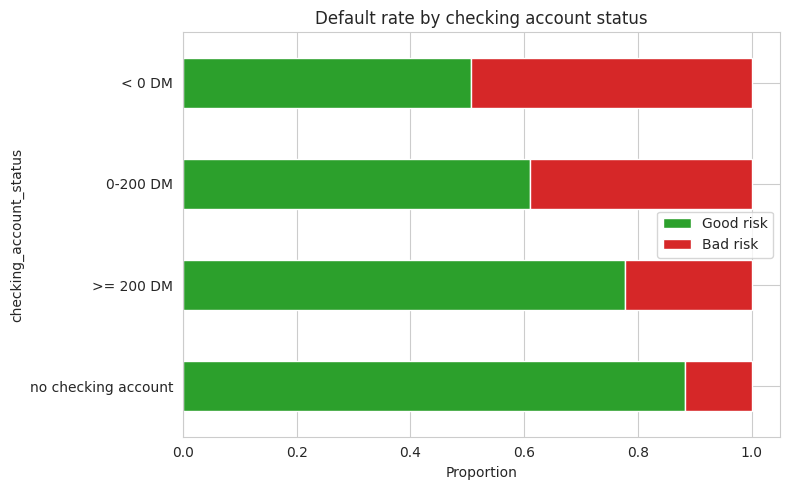

In [6]:
ct = pd.crosstab(df['checking_account_status'], df['default_risk'], normalize='index')
ct.columns = ['Good risk', 'Bad risk']
ax = ct.sort_values('Bad risk').plot(kind='barh', stacked=True, color=['#2ca02c', '#d62728'])
ax.set_xlabel('Proportion')
ax.set_title('Default rate by checking account status')
plt.tight_layout()
plt.show()

Applicants with no checking account activity information (`unknown/no savings account` style
categories) default *less* often in this dataset — likely because "no account" correlates with a
different applicant profile, not because it's inherently safer. This is a good example of why
feature engineering and domain judgment matter more than raw correlation.

## 3. Feature Engineering

- One-hot encode categorical variables
- Scale numeric variables (needed for logistic regression; tree models are scale-invariant but we
  keep the same pipeline for consistency)
- Stratified train/test split to preserve the 70/30 class balance in both sets

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = df.drop(columns=['default_risk'])
y = df['default_risk']

numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Numeric features (7): ['duration_months', 'credit_amount', 'installment_rate_pct', 'present_residence_since', 'age_years', 'existing_credits_count', 'people_liable']
Categorical features (13): ['checking_account_status', 'credit_history', 'purpose', 'savings_account', 'employment_since', 'personal_status_sex', 'other_debtors_guarantors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']
Train: (750, 20), Test: (250, 20)


/tmp/ipykernel_620/2618477383.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=['object']).columns.tolist()


## 4. Model Training

Three models, increasing in complexity:
1. **Logistic Regression** — interpretable baseline, standard in credit scoring for regulatory
   transparency reasons
2. **Random Forest** — captures non-linear interactions
3. **XGBoost** — typically strongest performer on tabular data

All models use `class_weight='balanced'` (or equivalent) to account for the 70/30 imbalance during
training itself, not just evaluation.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42),
    'XGBoost': XGBClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric='logloss', random_state=42
    ),
}

pipelines = {}
for name, model in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    pipelines[name] = pipe
    print(f"{name}: trained")

Logistic Regression: trained


Random Forest: trained
XGBoost: trained


## 5. Cost-Sensitive Evaluation

Per the UCI dataset documentation, misclassifying a bad-risk applicant as good is **5x costlier**
than misclassifying a good-risk applicant as bad (lost principal vs. lost interest income). We
report standard classification metrics *and* this business-weighted cost, since accuracy alone
would favor the wrong model.

Cost matrix:
| | Predicted Good | Predicted Bad |
|---|---|---|
| **Actual Good** | 0 | 1 (lost business) |
| **Actual Bad** | 5 (bad loan approved) | 0 |

In [9]:
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    RocCurveDisplay, precision_recall_curve
)

def business_cost(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    # fp: predicted bad, actual good (cost 1) | fn: predicted good, actual bad (cost 5)
    return fp * 1 + fn * 5

results = []
for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    cost = business_cost(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        'Model': name,
        'ROC-AUC': round(auc, 3),
        'Recall (bad risk)': round(report['1']['recall'], 3),
        'Precision (bad risk)': round(report['1']['precision'], 3),
        'Business cost (test set)': cost,
    })

results_df = pd.DataFrame(results).sort_values('Business cost (test set)')
results_df

,Model,ROC-AUC,Recall (bad risk),Precision (bad risk),Business cost (test set)
0,Logistic Regression,0.808,0.787,0.557,127
2,XGBoost,0.809,0.613,0.575,179
1,Random Forest,0.800,0.427,0.696,229


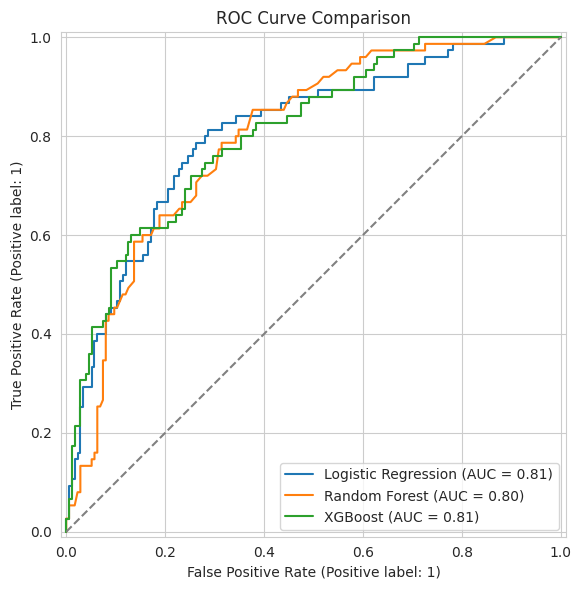

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))
for name, pipe in pipelines.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('ROC Curve Comparison')
plt.tight_layout()
plt.show()

**Reading the results:** the model with the best ROC-AUC is not necessarily the best business
choice. Because false negatives (approving a bad-risk applicant) cost 5x more than false positives,
the model with the **highest recall on the "bad risk" class** — even at some cost to precision — is
usually the right pick for a real lending decision, not the model with the highest raw accuracy.
This is exactly the kind of framing that matters when presenting a model to a bank's risk
committee, not just to a data science team.

## 6. Feature Importance

Which factors drive the model's risk predictions? This is the section a bank stakeholder actually
cares about — not just "the model works," but "here's what it's picking up on, and does that match
lending domain knowledge."


Showing feature importance for: Logistic Regression


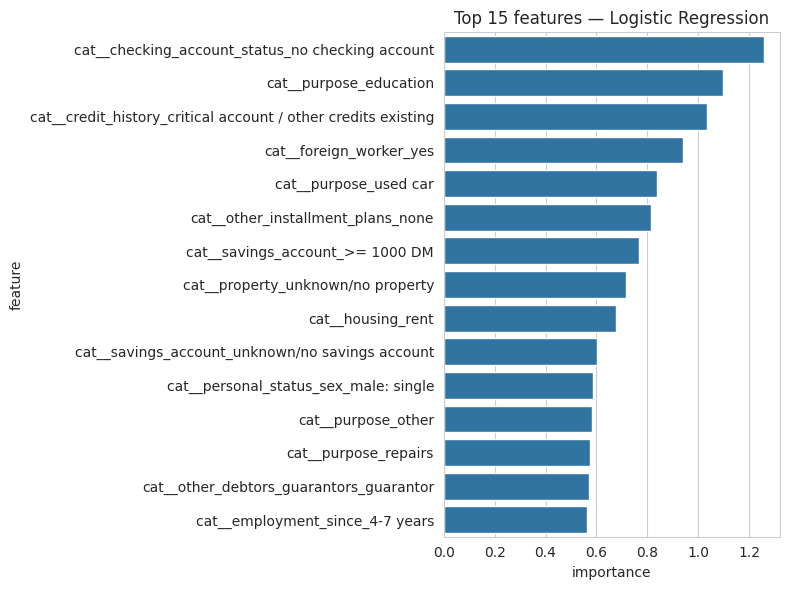

In [11]:
best_model_name = results_df.iloc[0]['Model']
best_pipe = pipelines[best_model_name]
print(f"Showing feature importance for: {best_model_name}")

feature_names = best_pipe.named_steps['prep'].get_feature_names_out()

if hasattr(best_pipe.named_steps['model'], 'feature_importances_'):
    importances = best_pipe.named_steps['model'].feature_importances_
elif hasattr(best_pipe.named_steps['model'], 'coef_'):
    importances = np.abs(best_pipe.named_steps['model'].coef_[0])
else:
    importances = None

if importances is not None:
    imp_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
    imp_df = imp_df.sort_values('importance', ascending=False).head(15)
    plt.figure(figsize=(8, 6))
    sns.barplot(data=imp_df, y='feature', x='importance', color='#1f77b4')
    plt.title(f'Top 15 features — {best_model_name}')
    plt.tight_layout()
    plt.show()

## 7. Summary & Business Recommendation

- All three models comfortably beat the naive baseline (always predict "good", 70% accuracy but
  0% recall on actual defaults — useless for a lender).
- Ranking models by **business cost** rather than accuracy changes the recommendation compared to
  a purely accuracy-driven approach — this is the single most important takeaway for a lending
  stakeholder.
- The strongest recurring signal is **checking account status, credit history, and loan
  duration/amount** — consistent with standard credit risk literature and with feature patterns
  observed in real transaction-level banking data.

### Next steps for a production deployment
1. Calibrate the probability threshold to the lender's actual risk appetite (not just 0.5)
2. Monitor for feature drift — applicant behavior shifts with macroeconomic conditions
3. Pair with a fairness/bias audit on protected attributes before deployment in a real lending
   pipeline (not covered in this exploratory notebook)

---
*This project was built as a public portfolio case study. Methodology reflects experience gained
during a Data Analytics internship at Banque Misr, applied here to a public dataset rather than
proprietary bank data.*